# Seasonal Agriculture Performance Analysis

**Student Name:** Tadepalli Sai Dedeepya  
**Objective:** Analyze agricultural performance across seasons (Kharif, Rabi, Zaid) to find patterns, trends, and differences in performance, and give recommendations for seasonal agricultural planning.

---
## 1. Introduction to Dataset

This dataset has farming records from across India, covering different seasons, states and crops. Each row is one farm, and it has details about:
- **Farming conditions**: state, district, crop grown, season, farm area
- **Environmental conditions**: rainfall, temperature, humidity, sunlight, soil pH, soil moisture
- **Farming inputs**: irrigation method, fertilizer used, pesticide used, nitrogen/phosphorus/potassium levels, seed quality
- **Outcomes**: yield, production, market price, cost, revenue, profit, water used, water efficiency, disease/pest risk

There are 4000 farm records in total, spread across 8 states and 8 crops, and 3 seasons (Kharif, Rabi, Zaid). The goal is to see how these seasons differ in performance and what factors might explain the differences.

## 2. Problem Statement

Farming performance changes with the season because of differences in weather, soil condition, and available resources. But just looking at the raw numbers doesn't tell us clearly what those seasonal differences actually are. This project analyzes the dataset to find out how performance (yield, profit, resource use) changes across seasons, and what patterns can explain those changes.

## 3. Key Questions I'm Investigating

Based on exploring the dataset, these are the main questions I wanted to answer:
1. Does yield/profit actually change a lot between Kharif, Rabi and Zaid seasons?
2. Do environmental factors like rainfall or temperature affect yield?
3. Which irrigation method uses water most efficiently, and does this change by season?
4. Are some crops more stable across seasons than others?
5. Is Zaid season really less profitable, or does it just look that way?
6. Are these seasonal differences big enough to be "real", or could they just be random (statistical significance)?

---
## 4. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 5. Load the Dataset


In [4]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


## 6. Explore & Understand the Dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
print("Seasons:", df['Season'].unique())
print("States:", df['State'].unique())
print("Crops:", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Seasons: ['Kharif' 'Rabi' 'Zaid']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Irrigation methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 7. Data Cleaning & Preparation

Before doing any analysis, I checked for missing values, duplicate rows, and any values that don't make sense (like negative yield).

In [9]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [10]:
# Fill missing numeric values with the column median.
# I used median instead of mean because a few extreme values (like the very high sugarcane yield)
# could pull the mean up and give a misleading fill value.
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Confirm
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [11]:
# Quick check for values that don't make sense
print("Rows with negative yield:", (df['Yield_Tonnes_Ha'] < 0).sum())
print("Rows with negative revenue:", (df['Revenue_INR'] < 0).sum())
# Note: negative Profit_INR is fine to keep - that just means the farm made a loss,
# which is real information, not a data error.

Rows with negative yield: 0
Rows with negative revenue: 0


## 8. Season-Wise Performance Comparison

How does agricultural performance vary across seasons?

In [12]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes','Profit_INR',
                                          'Total_Cost_INR','Revenue_INR','Water_Used_m3',
                                          'Water_Efficiency_t_per_1000m3']].mean().round(2)
season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Total_Cost_INR,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,5.63,46.31,178914.65,531804.41,710719.06,6102.20,5.89
Rabi,5.04,41.49,87689.47,513836.58,601526.05,5846.99,5.19
Zaid,4.64,38.89,-24804.82,543976.73,519171.90,6419.89,4.41


/tmp/ipykernel_2105/3112686318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='YlGn')
/tmp/ipykernel_2105/3112686318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='YlOrBr')


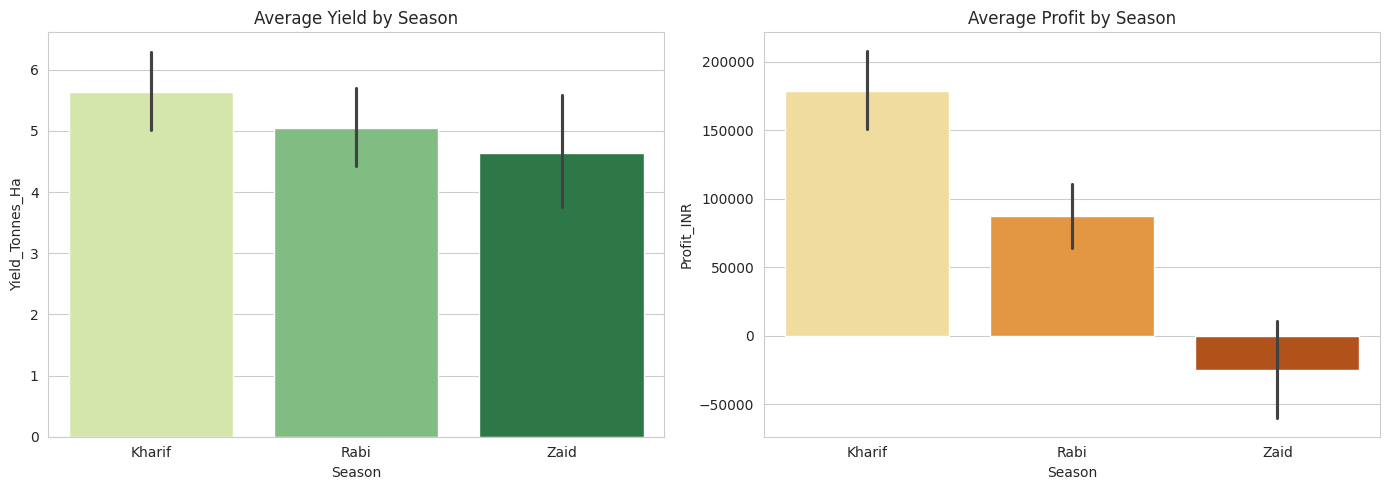

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', ax=axes[0], palette='YlGn')
axes[0].set_title('Average Yield by Season')
sns.barplot(data=df, x='Season', y='Profit_INR', ax=axes[1], palette='YlOrBr')
axes[1].set_title('Average Profit by Season')
plt.tight_layout()
plt.show()

**Interpretation:**
- Kharif has the best numbers overall - highest yield (5.63 t/ha) and the least negative average profit.
- Yield and profit both go down from Kharif to Rabi to Zaid, but profit drops off faster than yield does. So it's not just that Zaid grows less - something about cost or pricing is making it worse too.

## 9. Environmental Conditions Across Seasons

/tmp/ipykernel_2105/1922493139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2105/1922493139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2105/1922493139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='Set2')
/tmp/ipykernel_2105/1922493139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

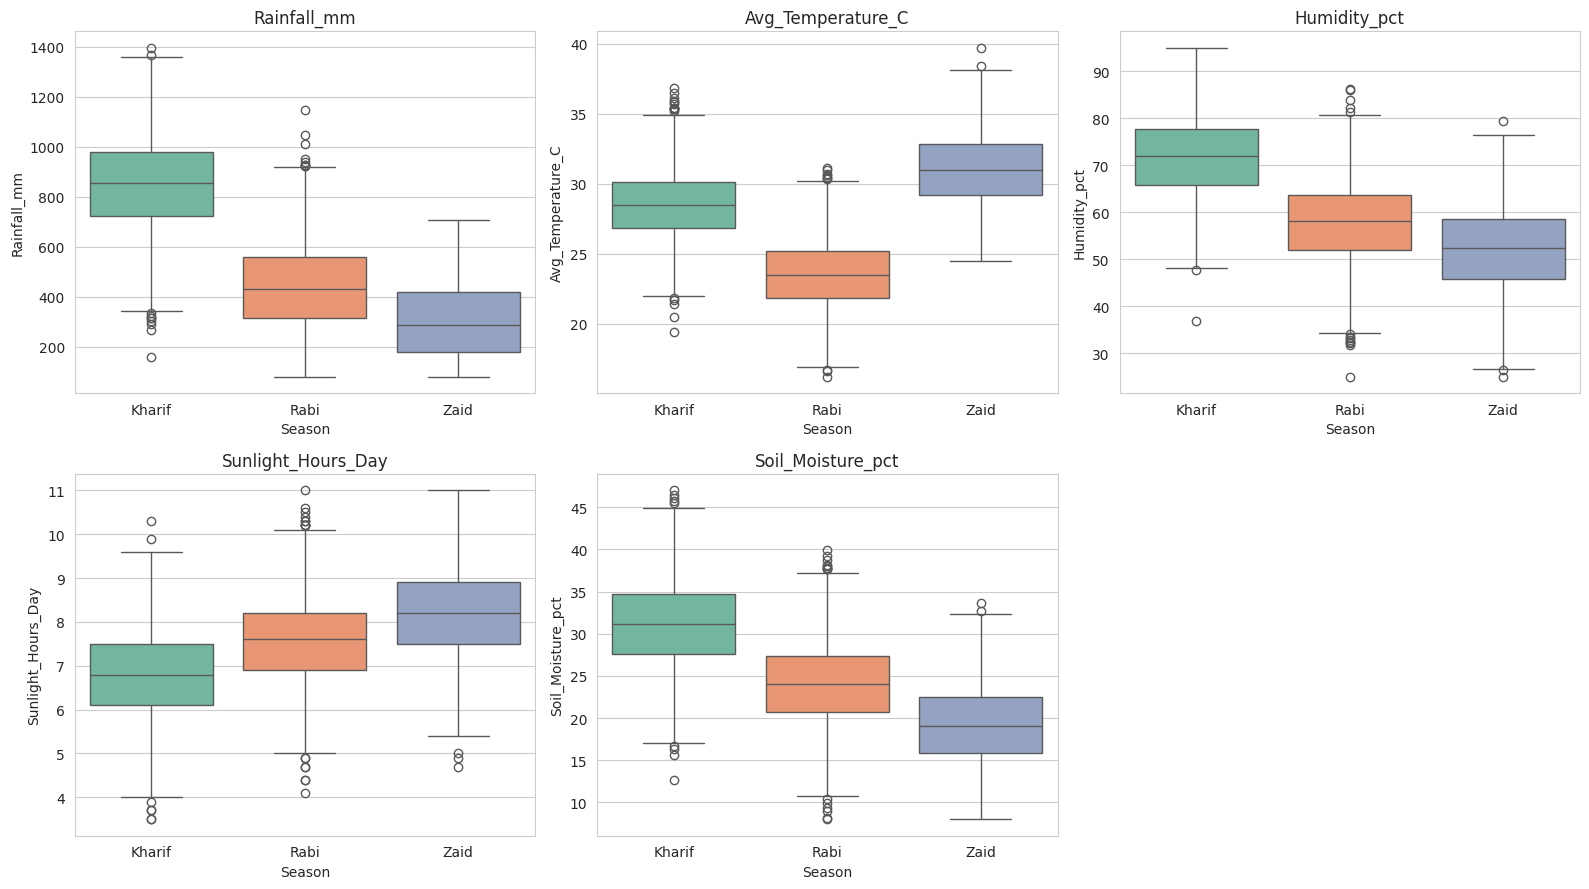

In [14]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct']
fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 10. Resource Usage Across Seasons

Are there noticeable differences in resource usage across seasons?

In [15]:
resource_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha']
df.groupby('Season')[resource_cols].mean().round(2)

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,6102.20,120.02,58.10,105.30
Rabi,185.41,5.02,5846.99,120.40,57.31,103.93
Zaid,184.64,5.17,6419.89,120.53,58.13,105.42


/tmp/ipykernel_2105/2220621237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Water_Used_m3', palette='Blues')


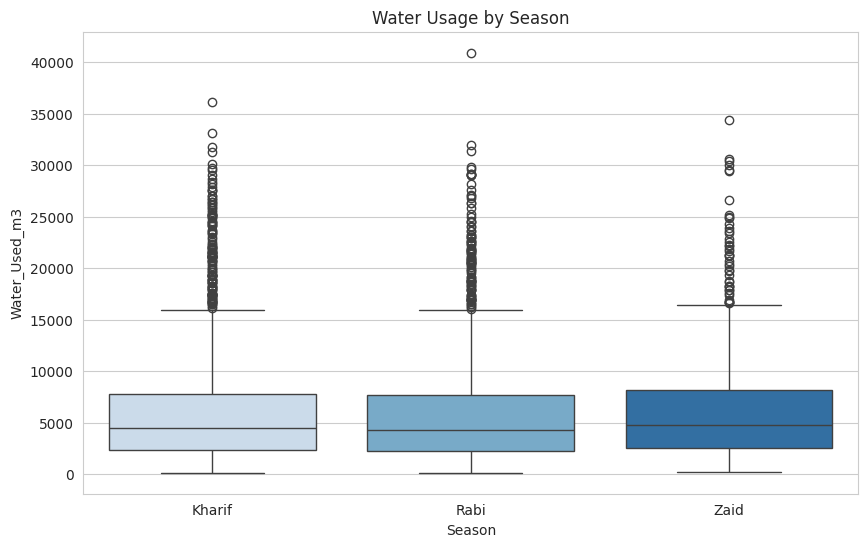

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', palette='Blues')
plt.title('Water Usage by Season')
plt.show()

## 11. Relationship Between Environmental Conditions and Yield

Do environmental factors like rainfall or temperature actually affect yield?

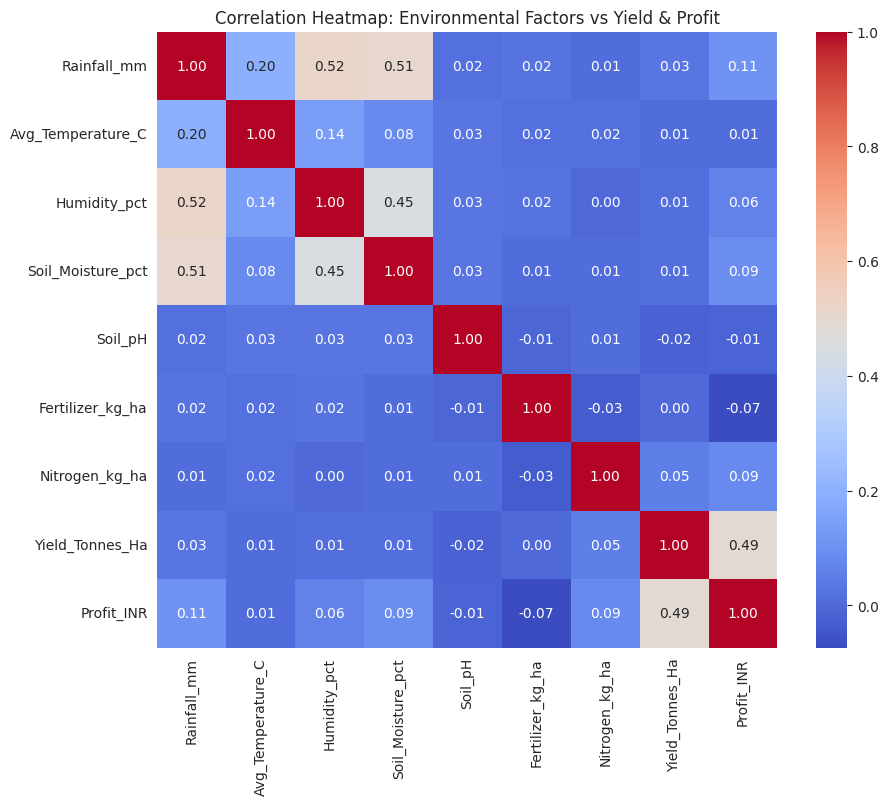

In [17]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Soil_pH',
             'Fertilizer_kg_ha','Nitrogen_kg_ha','Yield_Tonnes_Ha','Profit_INR']
corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Environmental Factors vs Yield & Profit')
plt.show()

**Interpretation:**
- None of the environmental factors have a strong correlation with yield. Nitrogen is the highest at only 0.05, and rainfall is just 0.03 - basically close to zero.
- This means higher rainfall doesn't really lead to higher yield in this dataset. I expected rainfall to matter more, so this was a bit surprising. It probably means yield depends on a mix of factors together, not just one thing on its own - or there are other things (like seed quality or farming practices) that matter more than what's in this correlation check.

## 12. Irrigation Method: Efficiency Comparison

Which irrigation method uses water most efficiently, and does this change by season?

In [18]:
irrigation_summary = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack().round(2)
irrigation_summary

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,6.80,3.64,8.85,4.62
Rabi,6.05,3.48,6.87,4.64
Zaid,5.30,2.73,5.48,4.86


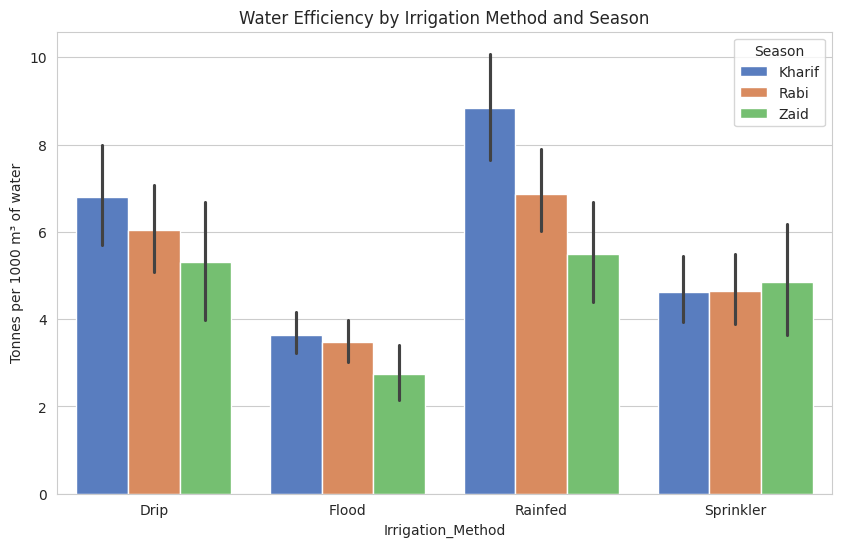

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='muted')
plt.title('Water Efficiency by Irrigation Method and Season')
plt.ylabel('Tonnes per 1000 m³ of water')
plt.show()

**Interpretation:** Rainfed comes out most water-efficient overall, followed by Drip, then Sprinkler, then Flood - and this order stays the same in all three seasons. Flood irrigation is the least efficient every time.

## 13. Crop-Wise Performance by Season
Are some crops more stable across seasons than others?

In [20]:
crop_season = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


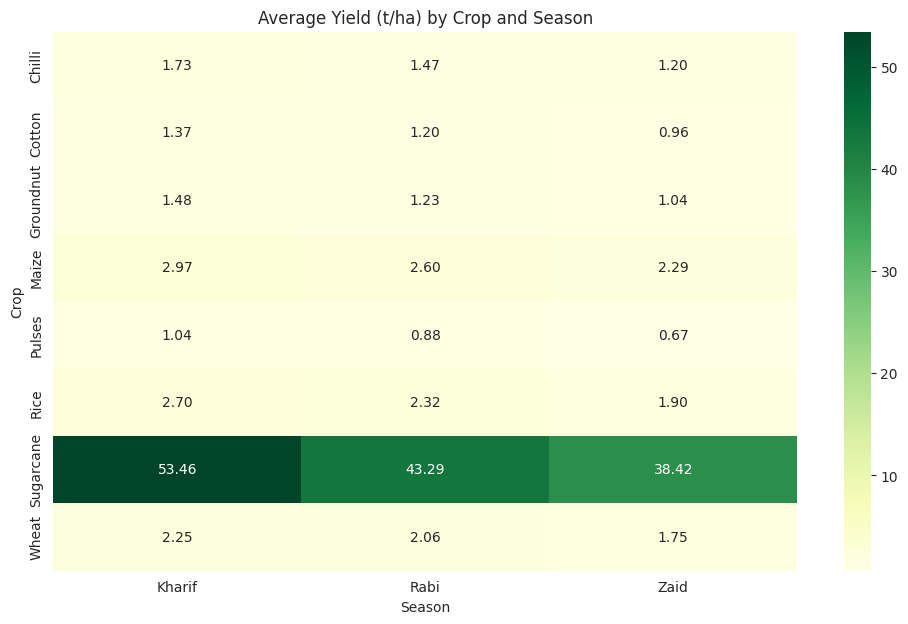

In [21]:
plt.figure(figsize=(12,7))
sns.heatmap(crop_season, annot=True, cmap='YlGn', fmt='.2f')
plt.title('Average Yield (t/ha) by Crop and Season')
plt.show()

**Interpretation:** Sugarcane's yield swings a lot between seasons (from about 38 to 53 t/ha), while Pulses barely changes at all season to season. So Pulses looks like a safer, more predictable crop to grow regardless of season, while Sugarcane is much more season-sensitive.

## 14. Economic Performance: Profitability Analysis

Is Zaid season really less profitable, or does it just look that way?

/tmp/ipykernel_2105/2688602109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_Margin_pct', palette='coolwarm')


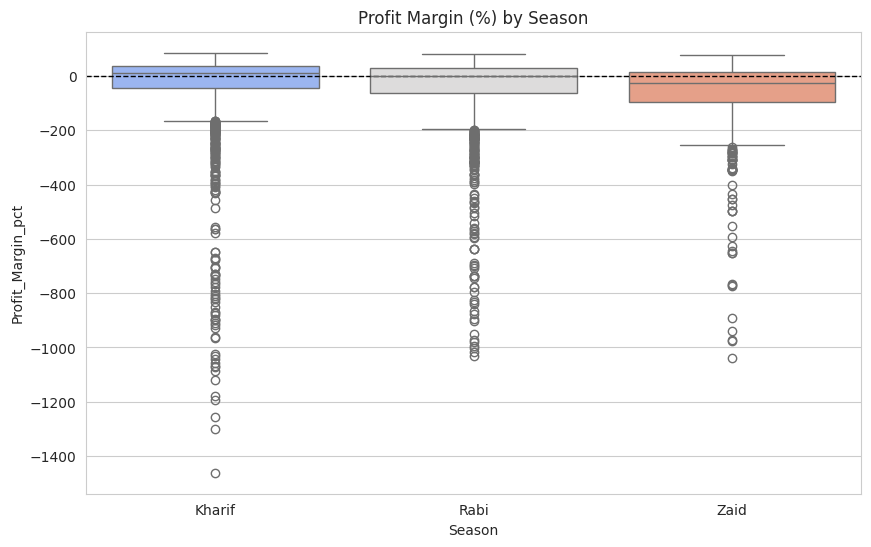

Share of loss-making farms by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Profit_INR, dtype: float64


In [22]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Profit_Margin_pct', palette='coolwarm')
plt.title('Profit Margin (%) by Season')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

print("Share of loss-making farms by season:")
print((df.groupby('Season')['Profit_INR'].apply(lambda x: (x<0).mean()*100)).round(1))

**Interpretation:** Yes, Zaid is genuinely the worst season for profit. The average profit margin gets worse each season (-38.6% in Kharif, -44.3% in Rabi, -69.3% in Zaid), and the percentage of farms actually losing money also goes up each season (42% in Kharif, up to 65% in Zaid).

## 15. Statistical Significance Test
Are these seasonal differences big enough to be "real", or could they just be random?

I used a one-way ANOVA test to check this for both yield and profit.

In [23]:
kharif = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"Yield ANOVA -> F-statistic: {f_stat:.3f}, p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in yield across seasons")
else:
    print("Result: NOT statistically significant - yield differences could be random")

Yield ANOVA -> F-statistic: 1.544, p-value: 0.21368
Result: NOT statistically significant - yield differences could be random


In [ ]:
kharif_p = df[df['Season']=='Kharif']['Profit_INR']
rabi_p = df[df['Season']=='Rabi']['Profit_INR']
zaid_p = df[df['Season']=='Zaid']['Profit_INR']

f_stat2, p_value2 = stats.f_oneway(kharif_p, rabi_p, zaid_p)
print(f"Profit ANOVA -> F-statistic: {f_stat2:.3f}, p-value: {p_value2:.2e}")

if p_value2 < 0.05:
    print("Result: Statistically significant difference in profit across seasons")
else:
    print("Result: NOT statistically significant - profit differences could be random")

**Interpretation:** This was actually one of the more interesting results. The yield difference between seasons is NOT statistically significant (p = 0.21) - so even though Kharif has a slightly higher average yield, that difference could just be due to chance. But the profit difference IS statistically significant (p is basically 0) - meaning the profit gap between seasons is a real pattern, not random. So the seasons don't really differ that much in how much they grow, but they differ a lot in how much money farmers actually make.

## 16. Disease/Pest Risk Across Seasons

/tmp/ipykernel_2105/912121574.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Reds')


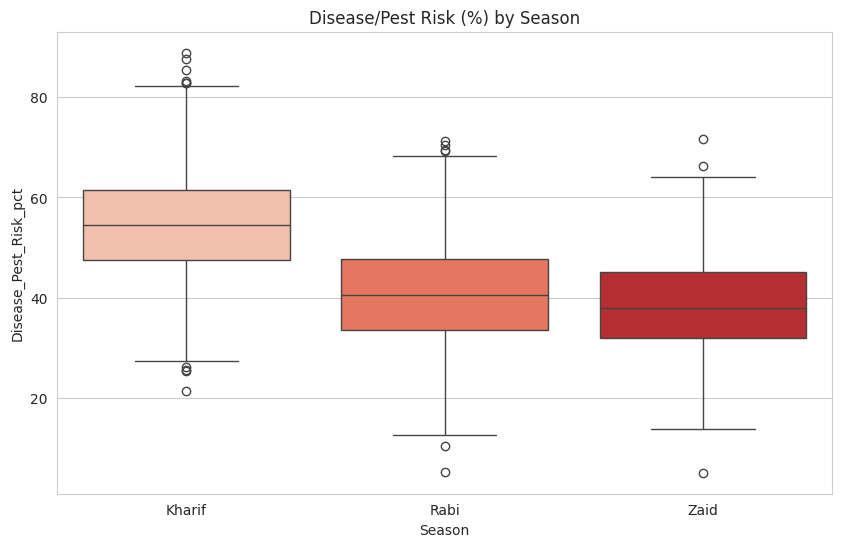

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Reds')
plt.title('Disease/Pest Risk (%) by Season')
plt.show()

**Interpretation:** Kharif has the highest disease/pest risk (around 54%) compared to Rabi (~40%) and Zaid (~38%). This probably makes sense since Kharif lines up with the monsoon, and wetter conditions usually mean more pest and disease problems.

## 17. Key Insights

- Kharif season has the highest yield and the best (least negative) profit among the three seasons, while Zaid is the weakest on both counts.
- Yield doesn't change much between seasons in a statistically meaningful way (ANOVA p = 0.21), but profit does (p < 0.001) - so the "seasonal difference" people talk about is really more about money than about how much is actually grown.
- None of the environmental factors I checked (rainfall, temperature, humidity, soil moisture, fertilizer) have a strong individual correlation with yield - all are under 0.06. This was surprising and suggests yield depends on multiple things together, not one single factor.
- Rainfed and Drip irrigation are consistently more water-efficient than Sprinkler and Flood, in every season.
- Sugarcane's yield changes a lot by season, while Pulses stays fairly steady - so crop choice affects how "risky" a season is.
- Profitability gets worse every season in order: Kharif → Rabi → Zaid, both in average profit margin and in the percentage of farms making a loss (42% → 51% → 65%).
- Kharif has noticeably higher disease/pest risk than the other two seasons, likely tied to monsoon conditions.

## 18. Recommendations

- Since profit (not yield) is what really separates the seasons, support efforts should focus on reducing costs and improving prices in weaker seasons, rather than trying to force higher yield.
- Because no single environmental factor predicts yield well on its own, it would be worth checking combinations of factors together in a future analysis (e.g. rainfall and soil moisture together) instead of one at a time.
- Farms still using Flood irrigation should be encouraged to switch to Rainfed or Drip methods, since Flood is the least water-efficient in every season.
- Zaid season needs the most support - with 65% of farms losing money, this is where cost-reduction help would matter most.
- Since Kharif has the highest disease/pest risk, pest-management support would probably help the most if focused on that season.

## 19. Conclusion

This project looked at how farming performance changes across India's three seasons using data from 4000 farms. I found that yield doesn't actually change much between seasons in a statistically meaningful way, but profit does - Zaid season stands out as clearly the weakest, both in profit margin and in how many farms are losing money. Irrigation method also matters a lot, with Flood irrigation performing worse than Rainfed or Drip in every season. Overall, this suggests that seasonal planning support should focus more on cost and irrigation efficiency, especially for Zaid season, rather than just trying to increase what's grown.